<a href="https://colab.research.google.com/github/INTROESPACIAL20261/pantilla0/blob/main/reubicarEstacionesdeGas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [147]:
!pip install osmnx mapclassify

In [148]:
import geopandas as gpd

filez = "https://github.com/INTROESPACIAL20261/pantilla0/raw/main/2020_Census_Tracts_Seattle_8661193084158732132.zip"

seattleTracts = gpd.read_file(filez)
seattleTracts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   GEOID20     177 non-null    object  
 1   GROSS_ACRE  177 non-null    float64 
 2   LAND_ACRES  177 non-null    float64 
 3   WATER_ACRE  177 non-null    float64 
 4   NAME        177 non-null    object  
 5   TRACT_NUMB  177 non-null    int64   
 6   BASENAME    177 non-null    object  
 7   UVDA_AREA   177 non-null    object  
 8   CRA_NO      177 non-null    float64 
 9   CRA_GRP     177 non-null    int32   
 10  GEN_ALIAS   177 non-null    object  
 11  DETL_NAMES  177 non-null    object  
 12  C_DISTRICT  177 non-null    int64   
 13  geometry    177 non-null    geometry
dtypes: float64(4), geometry(1), int32(1), int64(2), object(6)
memory usage: 18.8+ KB


In [149]:
seattleTracts.head()

,GEOID20,GROSS_ACRE,LAND_ACRES,WATER_ACRE,NAME,TRACT_NUMB,BASENAME,UVDA_AREA,CRA_NO,CRA_GRP,GEN_ALIAS,DETL_NAMES,C_DISTRICT,geometry
0,53033000402,444.493643,444.527261,0.000000,Census Tract 4.02,402,4.02,Bitter Lake Village,9.1,9,Broadview/Bitter Lake,"Broadview, Bitter Lake",5,"POLYGON ((1267598.433 267477.138, 1267788.924 ..."
1,53033000403,180.930716,165.408389,15.535762,Census Tract 4.03,403,4.03,Bitter Lake Village,9.1,9,Broadview/Bitter Lake,"Broadview, Bitter Lake",5,"POLYGON ((1265848.993 271492.767, 1265842.812 ..."
2,53033000700,319.838996,319.862596,0.000000,Census Tract 7,700,7,Lake City,8.2,8,Olympic Hills/Victory Heights,"Lake City, Victory Heights, Olympic Hills, Pin...",5,"POLYGON ((1277629.018 265876.292, 1277833.975 ..."
3,53033003302,154.942826,154.952619,0.000000,Census Tract 33.02,3302,33.02,Ballard,10.2,10,Whittier Heights,"Whittier Heights, Loyal Heights, Crown Hill",6,"POLYGON ((1262877.612 251639.607, 1262891.039 ..."
4,53033003601,166.571397,166.583375,0.000000,Census Tract 36.01,3601,36.01,Green Lake - Roosevelt,9.4,9,Green Lake,"Green Lake, Meridian, Roosevelt, Woodland Park",6,"POLYGON ((1274839.167 250046.877, 1274833.189 ..."


In [150]:
seattleTracts.crs

<Projected CRS: PROJCS["NAD83(HARN) / Washington North (ftUS)",GEO ...>
Name: NAD83(HARN) / Washington North (ftUS)
Axis Info [cartesian]:
- [east]: Easting (US survey foot)
- [north]: Northing (US survey foot)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Lambert Conic Conformal (2SP)
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [151]:
Seattle_crs = "EPSG:26910"

seattleTracts = seattleTracts.to_crs(Seattle_crs)
seattle = seattleTracts.dissolve()
seattle

,geometry,GEOID20,GROSS_ACRE,LAND_ACRES,WATER_ACRE,NAME,TRACT_NUMB,BASENAME,UVDA_AREA,CRA_NO,CRA_GRP,GEN_ALIAS,DETL_NAMES,C_DISTRICT
0,"MULTIPOLYGON (((547410.876 5261554.553, 547407...",53033000402,444.493643,444.527261,0.0,Census Tract 4.02,402,4.02,Bitter Lake Village,9.1,9,Broadview/Bitter Lake,"Broadview, Bitter Lake",5


<Axes: >

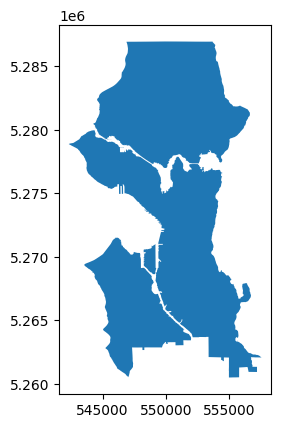

In [152]:
seattle.plot()

In [153]:
import osmnx as ox
stations = ox.features_from_place(
    "Seattle, Washington, USA",
    tags={'amenity': 'fuel'}
)

In [154]:
stations.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 127 entries, ('node', np.int64(457773031)) to ('way', np.int64(1460417274))
Data columns (total 70 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   geometry                   127 non-null    geometry
 1   amenity                    127 non-null    object  
 2   brand                      111 non-null    object  
 3   brand:wikidata             109 non-null    object  
 4   name                       121 non-null    object  
 5   addr:city                  44 non-null     object  
 6   addr:housenumber           47 non-null     object  
 7   addr:postcode              43 non-null     object  
 8   addr:street                47 non-null     object  
 9   check_date                 61 non-null     object  
 10  compressed_air             53 non-null     object  
 11  website                    34 non-null     object  
 12  opening_hours              36 

In [155]:
stations.reset_index(drop=False, inplace=True)
stations.head()

,element,id,geometry,amenity,brand,brand:wikidata,name,addr:city,addr:housenumber,addr:postcode,...,start_date,fuel:e85,contact:facebook,contact:instagram,contact:phone,contact:twitter,contact:youtube,covered,landuse,mapwithai:source
0,node,457773031,POINT (-122.39997 47.63939),fuel,Chevron,Q319642,Magnolia Chevron,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,631386821,POINT (-122.3203 47.62518),fuel,76,Q1658320,76,Seattle,915,98102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,771801423,POINT (-122.35525 47.73205),fuel,Chevron,Q319642,Chevron,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,1197964284,POINT (-122.32958 47.58001),fuel,Shell,Q110716465,Shell,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,1489962206,POINT (-122.32805 47.66483),fuel,7-Eleven,Q259340,7-Eleven,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [156]:
colsToKeep = ['element', 'name', 'geometry']

fuelSeattle = stations[colsToKeep].copy()
fuelSeattle = fuelSeattle.to_crs(Seattle_crs)

fuelSeattle.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   element   127 non-null    object  
 1   name      121 non-null    object  
 2   geometry  127 non-null    geometry
dtypes: geometry(1), object(2)
memory usage: 3.1+ KB


In [157]:
fuelSeattle.fillna({'name': 'Unknown'}, inplace=True)

fuelSeattle['newname'] = fuelSeattle.index.astype(str) + "_" + fuelSeattle.name
fuelSeattle.set_index('newname', inplace=True)
fuelSeattle.drop(columns=['name'], inplace=True)

fuelSeattle.head()

,element,geometry
newname,,
0_Magnolia Chevron,node,POINT (545070.577 5276395.041)
1_76,node,POINT (551068.412 5274865.552)
2_Chevron,node,POINT (548343.649 5286720.849)
3_Shell,node,POINT (550414.847 5269839.108)
4_7-Eleven,node,POINT (550448.153 5279266.856)


In [158]:
import pandas as pd

pd.crosstab(fuelSeattle.element, fuelSeattle.geometry.geom_type, margins=True)

col_0,Point,Polygon,All
element,,,
node,15,0,15
way,0,112,112
All,15,112,127


In [159]:
schools = ox.features_from_place(
    "Seattle, Washington, USA",
    tags={'amenity': 'school'}
)

schools.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 217 entries, ('node', np.int64(356540545)) to ('way', np.int64(1442890189))
Data columns (total 71 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   geometry                 217 non-null    geometry
 1   amenity                  217 non-null    object  
 2   check_date               23 non-null     object  
 3   ele                      140 non-null    object  
 4   gnis:feature_id          146 non-null    object  
 5   name                     215 non-null    object  
 6   addr:city                153 non-null    object  
 7   addr:housenumber         163 non-null    object  
 8   addr:postcode            152 non-null    object  
 9   addr:street              163 non-null    object  
 10  religion                 25 non-null     object  
 11  name:etymology:wikidata  18 non-null     object  
 12  denomination             13 non-null     object  
 13  edu

In [160]:
schools.reset_index(inplace=True)

schoolSeattle = schools[['element', 'name', 'geometry']].copy()
schoolSeattle.fillna({'name': 'Unknown'}, inplace=True)

schoolSeattle['newname'] = schoolSeattle.index.astype(str) + "_" + schoolSeattle.name
schoolSeattle.set_index('newname', inplace=True)
schoolSeattle.drop(columns=['name'], inplace=True)

schoolSeattle = schoolSeattle.to_crs(Seattle_crs)

schoolSeattle.head()

,element,geometry
newname,,
0_Mapleleaf School,node,POINT (552925.436 5283350.335)
1_Hazel Wolf K-8,node,POINT (550876.028 5280652.219)
2_Epic Life Academy,node,POINT (549394.116 5283758.769)
3_Christ the King Elementary School,node,POINT (548515.145 5284662.849)
4_Assumption Saint Bridget School,node,POINT (553072.046 5280365.741)


In [161]:
pd.crosstab(schoolSeattle.element, schoolSeattle.geometry.geom_type, margins=True)

col_0,MultiPolygon,Point,Polygon,All
element,,,,
node,0,55,0,55
relation,4,0,2,6
way,0,0,156,156
All,4,55,158,217


<Axes: >

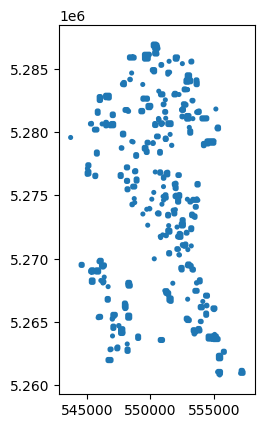

In [162]:
secured_schoolSeattle = schoolSeattle.copy()
secured_schoolSeattle['geometry'] = schoolSeattle.geometry.buffer(200)

secured_schoolSeattle.plot()

In [163]:
fuelSeattle.geometry.geom_type.value_counts()

,count
Polygon,112
Point,15


In [164]:
fuelSeattle_allPoly = fuelSeattle.copy()

fuelSeattle_allPoly['geometry'] = [
    station.buffer(10) if station.geom_type == 'Point' else station
    for station in fuelSeattle.geometry
]

In [165]:
fuelSeattle_allPoly.geometry.geom_type.value_counts()

,count
Polygon,127


In [166]:
gas_relocate = fuelSeattle_allPoly.sjoin(
    secured_schoolSeattle,
    how='inner',
    predicate='intersects'
)

gas_relocate.head()

,element_left,geometry,newname_right,element_right
newname_left,,,,
1_76,node,"POLYGON ((551078.412 5274865.552, 551078.363 5...",42_St. Nicholas School,node
1_76,node,"POLYGON ((551078.412 5274865.552, 551078.363 5...",153_Lowell Elementary School,way
3_Shell,node,"POLYGON ((550424.847 5269839.108, 550424.799 5...",18_Career Link School,node
11_Chevron,node,"POLYGON ((553783.029 5266126.575, 553782.981 5...",170_Aki Kurose Middle School,way
12_Gas & Smoke Depot,node,"POLYGON ((548171.175 5263445.807, 548171.127 5...",6_Learning Way School,node


In [167]:
is_duplicate = gas_relocate.index.duplicated(keep=False)

gas_relocate[is_duplicate]

,element_left,geometry,newname_right,element_right
newname_left,,,,
1_76,node,"POLYGON ((551078.412 5274865.552, 551078.363 5...",42_St. Nicholas School,node
1_76,node,"POLYGON ((551078.412 5274865.552, 551078.363 5...",153_Lowell Elementary School,way
23_Arco,way,"POLYGON ((552390.065 5272931.786, 552390.26 52...",77_Garfield High School,way
23_Arco,way,"POLYGON ((552390.065 5272931.786, 552390.26 52...",188_Nova High School,way
68_Shell,way,"POLYGON ((551874.231 5273802.685, 551871.234 5...",199_Seattle World School,way
68_Shell,way,"POLYGON ((551874.231 5273802.685, 551871.234 5...",117_Morningside Academy,way
68_Shell,way,"POLYGON ((551874.231 5273802.685, 551871.234 5...",52_The Hatch School,node
71_7-Eleven,way,"POLYGON ((551684.055 5273748.468, 551690.484 5...",199_Seattle World School,way
71_7-Eleven,way,"POLYGON ((551684.055 5273748.468, 551690.484 5...",117_Morningside Academy,way


In [168]:
gas_relocate = fuelSeattle_allPoly.sjoin(
    secured_schoolSeattle,
    how='inner',
    predicate='intersects'
)

gas_relocate = gas_relocate[~gas_relocate.index.duplicated(keep='first')]

In [169]:
gas_good = fuelSeattle.drop(index=gas_relocate.index)

print("Estaciones bien ubicadas:", len(gas_good))
print("Estaciones mal ubicadas:", len(gas_relocate))

Estaciones bien ubicadas: 101
Estaciones mal ubicadas: 26


In [170]:
base = secured_schoolSeattle.sjoin(
    gas_relocate,
    how='inner',
    predicate='intersects'
).explore(color='yellow', tiles='cartodbpositron')

gas_relocate.explore(m=base, color='red')

In [171]:
place = "Seattle, Washington, USA"
G = ox.graph_from_place(place, network_type="drive")
streets = ox.graph_to_gdfs(G, nodes=False, edges=True)

streets.shape

(50235, 15)

In [172]:
streets.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 50235 entries, (np.int64(29445663), np.int64(29485641), np.int64(0)) to (np.int64(13807144955), np.int64(30790011), np.int64(0))
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   osmid     50235 non-null  object  
 1   highway   50235 non-null  object  
 2   lanes     38709 non-null  object  
 3   maxspeed  49850 non-null  object  
 4   oneway    50235 non-null  bool    
 5   ref       747 non-null    object  
 6   reversed  50235 non-null  object  
 7   length    50235 non-null  float64 
 8   geometry  50235 non-null  geometry
 9   bridge    477 non-null    object  
 10  name      44902 non-null  object  
 11  junction  4743 non-null   object  
 12  tunnel    53 non-null     object  
 13  access    187 non-null    object  
 14  width     270 non-null    object  
dtypes: bool(1), float64(1), geometry(1), object(12)
memory usage: 7.0+ MB


In [173]:
streets.highway.value_counts().index

Index([                    'residential',                        'tertiary',
                             'secondary',                         'primary',
                          'unclassified',                   'motorway_link',
                                 'trunk',                        'motorway',
                        'secondary_link',                    'primary_link',
                         'tertiary_link',                   'living_street',
         ['residential', 'unclassified'],                      'trunk_link',
                                'busway',  ['living_street', 'residential'],
             ['residential', 'tertiary'],         ['tertiary', 'secondary'],
           ['motorway', 'motorway_link'],          ['secondary', 'primary'],
            ['tertiary', 'unclassified'],  ['residential', 'living_street'],
           ['residential', 'trunk_link'],    ['secondary_link', 'tertiary'],
            ['motorway_link', 'primary'],        ['trunk_link', 'tertiary'],

In [174]:
GAS_STATION_ROAD_TYPES = [
    'motorway',
    'primary',
    'trunk',
    'motorway_link',
    'primary_link',
    'trunk_link',
    ['motorway', 'trunk'],
    ['primary', 'motorway_link'],
    ['primary', 'primary_link']
]

suitable_roads = streets[streets.highway.isin(GAS_STATION_ROAD_TYPES)]

suitable_roads.shape

(2799, 15)

In [175]:
suitable_roads = suitable_roads.to_crs(seattle.crs)

In [176]:
competitionDistance = 100

fuelSeattle_allPoly_buffered = fuelSeattle_allPoly.buffer(competitionDistance)

In [177]:
secured_fuelSeattle_allPoly = gpd.GeoDataFrame(
    geometry=fuelSeattle_allPoly_buffered,
    crs=Seattle_crs
)

In [178]:
secured_areas_dissolved = secured_fuelSeattle_allPoly.overlay(
    secured_schoolSeattle,
    how='union',
    keep_geom_type=False
).dissolve()

secured_areas = gpd.GeoDataFrame(
    geometry=secured_areas_dissolved.geometry,
    crs=Seattle_crs
)

In [179]:
good_routes_forGas_dissolved = suitable_roads.overlay(
    secured_areas,
    keep_geom_type=False,
    how='difference'
).dissolve()

good_routes_forGas = gpd.GeoDataFrame(
    geometry=good_routes_forGas_dissolved.geometry,
    crs=Seattle_crs
)

good_routes_forGas

,geometry
0,"MULTILINESTRING ((551005.058 5276790.705, 5510..."


<Axes: >

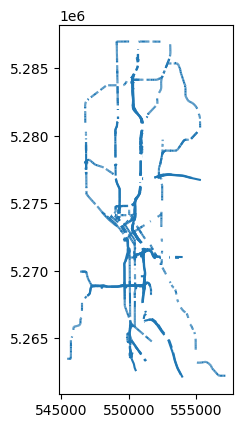

In [180]:
good_routes_forGas.plot()

In [181]:
potential_Locations = good_routes_forGas.copy()

newPOLYGONS = []
pointsComputed = 1
attempts = 1

while pointsComputed <= len(gas_relocate):

    candidatePoint = potential_Locations.sample_points(1)
    candidateStation = gpd.GeoDataFrame(
        geometry=candidatePoint.buffer(100),
        crs=Seattle_crs
    )

    if candidateStation.overlay(
        secured_areas,
        how='intersection',
        keep_geom_type=False
    ).empty:

        newPOLYGONS.append(candidateStation)
        pointsComputed += 1

        potential_Locations = potential_Locations.overlay(
            candidateStation,
            how='difference',
            keep_geom_type=False
        )

    if attempts > len(gas_relocate) * 10:
        break

    attempts += 1

attempts, len(newPOLYGONS)

(33, 26)

In [182]:
GoodLocationsGas_buffered_gdf = pd.concat(newPOLYGONS)

GoodLocationsGas_gdf = gpd.GeoDataFrame(
    geometry=GoodLocationsGas_buffered_gdf.centroid,
    crs=Seattle_crs
)

GoodLocationsGas_gdf

,geometry
0,POINT (550696.035 5271220.748)
0,POINT (551158.111 5270039.13)
0,POINT (550057.207 5271041.575)
0,POINT (549932.661 5265355.305)
0,POINT (549307.884 5274555.19)
0,POINT (550309.153 5272951.923)
0,POINT (550466.529 5274380.788)
0,POINT (550068.32 5264836.482)
0,POINT (551103.505 5270487.991)
0,POINT (551126.672 5268800.64)


Text(0.5, 1.0, 'Estaciones bien ubicadas, mal ubicadas y ubicaciones propuestas')

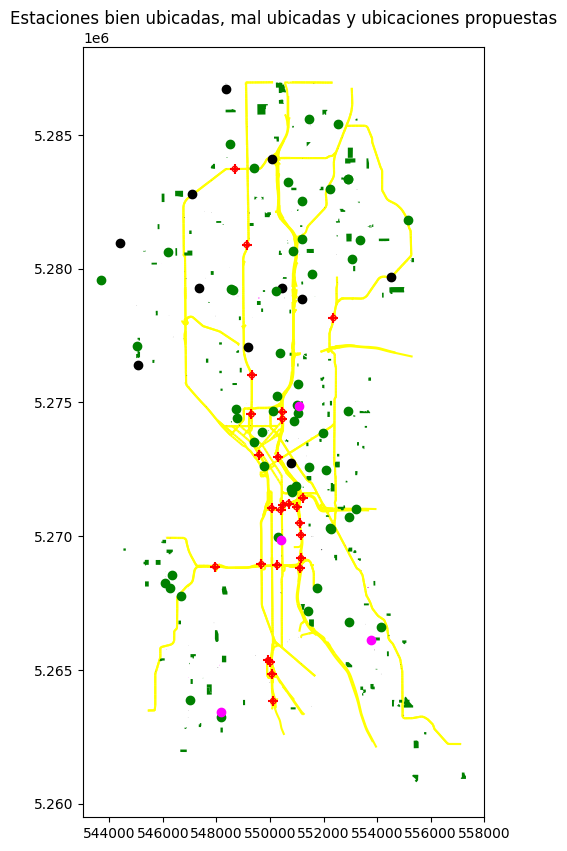

In [183]:
base = suitable_roads.plot(
    color='yellow',
    figsize=(10, 10),
    zorder=1
)

GoodLocationsGas_buffered_gdf.plot(
    ax=base,
    edgecolor='red',
    marker="+",
    facecolor='none',
    zorder=2
)

GoodLocationsGas_gdf.plot(
    ax=base,
    color='red',
    marker="+",
    markersize=50,
    zorder=3
)

gas_good.plot(
    ax=base,
    color='k',
    zorder=4
)

schoolSeattle.plot(
    ax=base,
    color='green',
    zorder=5
)

fuelSeattle.loc[gas_relocate.index].plot(
    ax=base,
    color='magenta',
    zorder=6
)

base.set_title("Estaciones bien ubicadas, mal ubicadas y ubicaciones propuestas")